In [5]:
import plotly.io as pio
pio.renderers.default = "vscode"

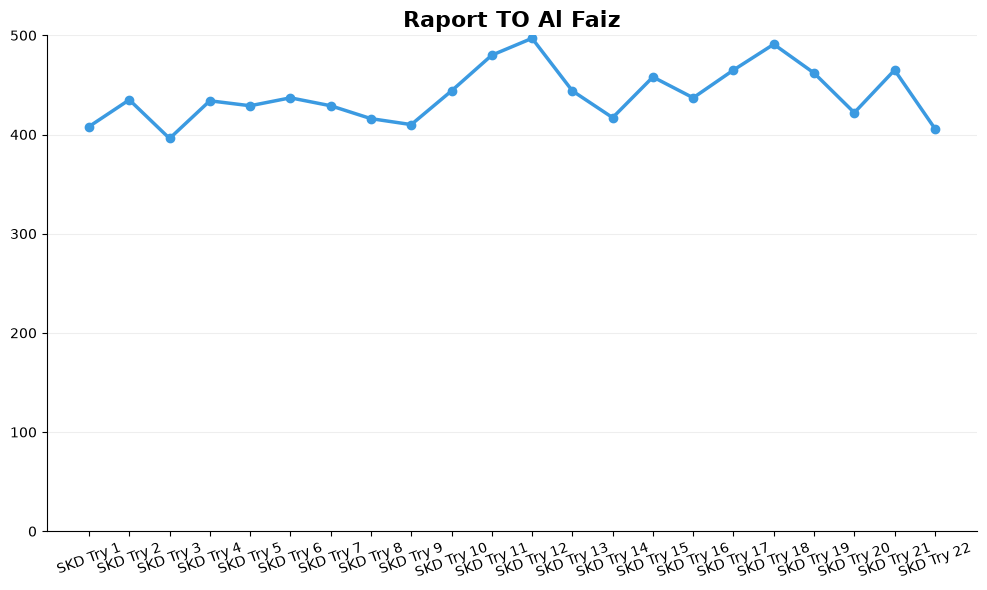

In [6]:
import matplotlib.pyplot as plt

labels = ["SKD Try 1", "SKD Try 2", "SKD Try 3", "SKD Try 4", "SKD Try 5", "SKD Try 6", "SKD Try 7", "SKD Try 8", "SKD Try 9",
          "SKD Try 10", "SKD Try 11", "SKD Try 12", "SKD Try 13", "SKD Try 14", "SKD Try 15", "SKD Try 16", "SKD Try 17", "SKD Try 18",
          "SKD Try 19", "SKD Try 20", "SKD Try 21", "SKD Try 22"]
data_score = [408, 435, 396, 434, 429, 437, 429, 416, 410, 444, 480, 497, 444, 417, 458, 437, 465, 491, 462, 422, 465, 406]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(labels, data_score, marker='o', color='#3B9AE1', label='Data Score', linewidth=2.5)

ax.set_ylim(0, 500)
ax.set_title("Raport TO Al Faiz", fontsize=16, fontweight='bold')
ax.grid(axis='y', color='#eee')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "DATA TRYOUT Boby.xlsx" 
df = pd.read_excel(file_path, sheet_name="Data SKD", header=4) 

df.columns = ["No", "Nama", "Tanggal", "TWK", "TIU", "TKP", "Total",
              "Target_TWK", "Target_TIU", "Target_TKP", "Status"]
df = df.dropna(subset=["No"])
df["No"] = df["No"].astype(int)

print(df.head())

   No          Nama    Tanggal    TWK    TIU    TKP  Total Target_TWK  \
0   1        FA [1] 2026-02-01   55.0  145.0  203.0  403.0      Tidak   
1   2        FA [2] 2026-02-09  100.0  125.0  206.0  431.0      Tidak   
2   3        FA [3] 2026-02-16  105.0  125.0  209.0  439.0      Tidak   
3   4        FA (4) 2026-03-14  110.0  125.0  209.0  444.0      Tidak   
4   5  Al Faiz [27] 2026-03-30   85.0  100.0  223.0  408.0      Tidak   

  Target_TIU Target_TKP          Status  
0      Lolos      Tidak  BELUM MEMENUHI  
1      Lolos      Lolos  BELUM MEMENUHI  
2      Lolos      Lolos  BELUM MEMENUHI  
3      Lolos      Lolos  BELUM MEMENUHI  
4      Tidak      Lolos  BELUM MEMENUHI  


In [8]:
PG_TWK, PG_TIU, PG_TKP = 65, 80, 166

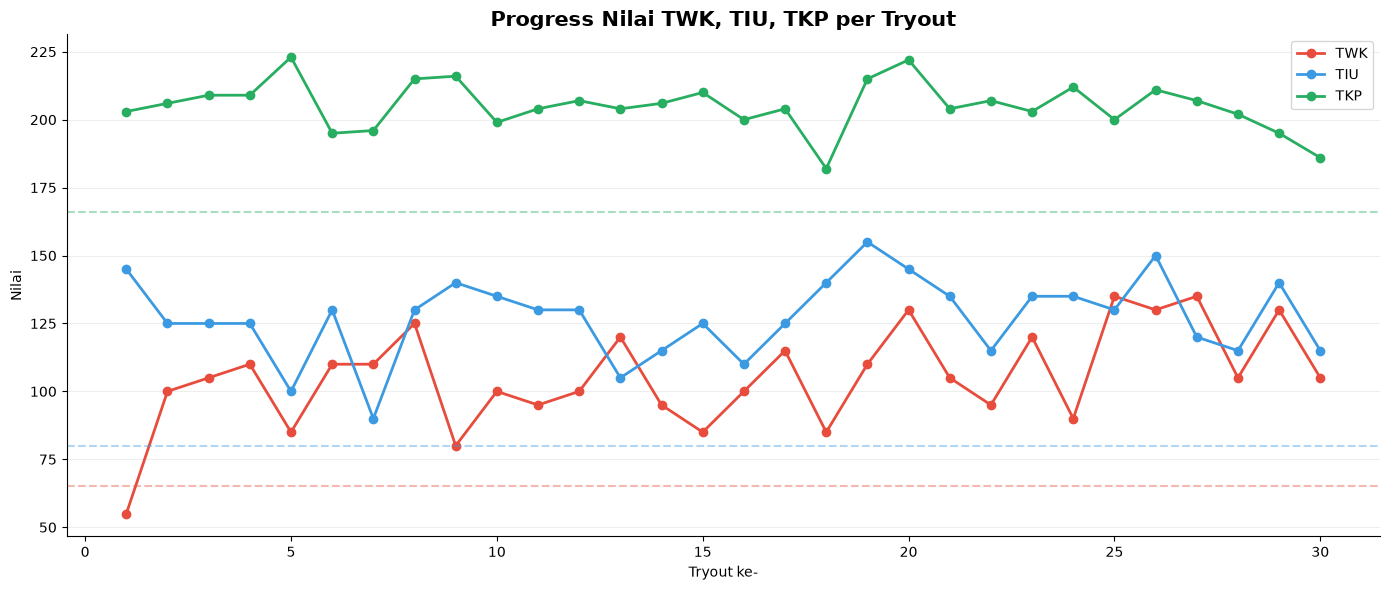

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df["No"], df["TWK"], marker='o', label='TWK', color='#E74C3C', linewidth=2)
ax.plot(df["No"], df["TIU"], marker='o', label='TIU', color='#3B9AE1', linewidth=2)
ax.plot(df["No"], df["TKP"], marker='o', label='TKP', color='#27AE60', linewidth=2)

ax.axhline(PG_TWK, color='#E74C3C', linestyle='--', alpha=0.4)
ax.axhline(PG_TIU, color='#3B9AE1', linestyle='--', alpha=0.4)
ax.axhline(PG_TKP, color='#27AE60', linestyle='--', alpha=0.4)

ax.set_title("Progress Nilai TWK, TIU, TKP per Tryout", fontsize=15, fontweight='bold')
ax.set_xlabel("Tryout ke-")
ax.set_ylabel("Nilai")
ax.legend()
ax.grid(axis='y', color='#eee')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

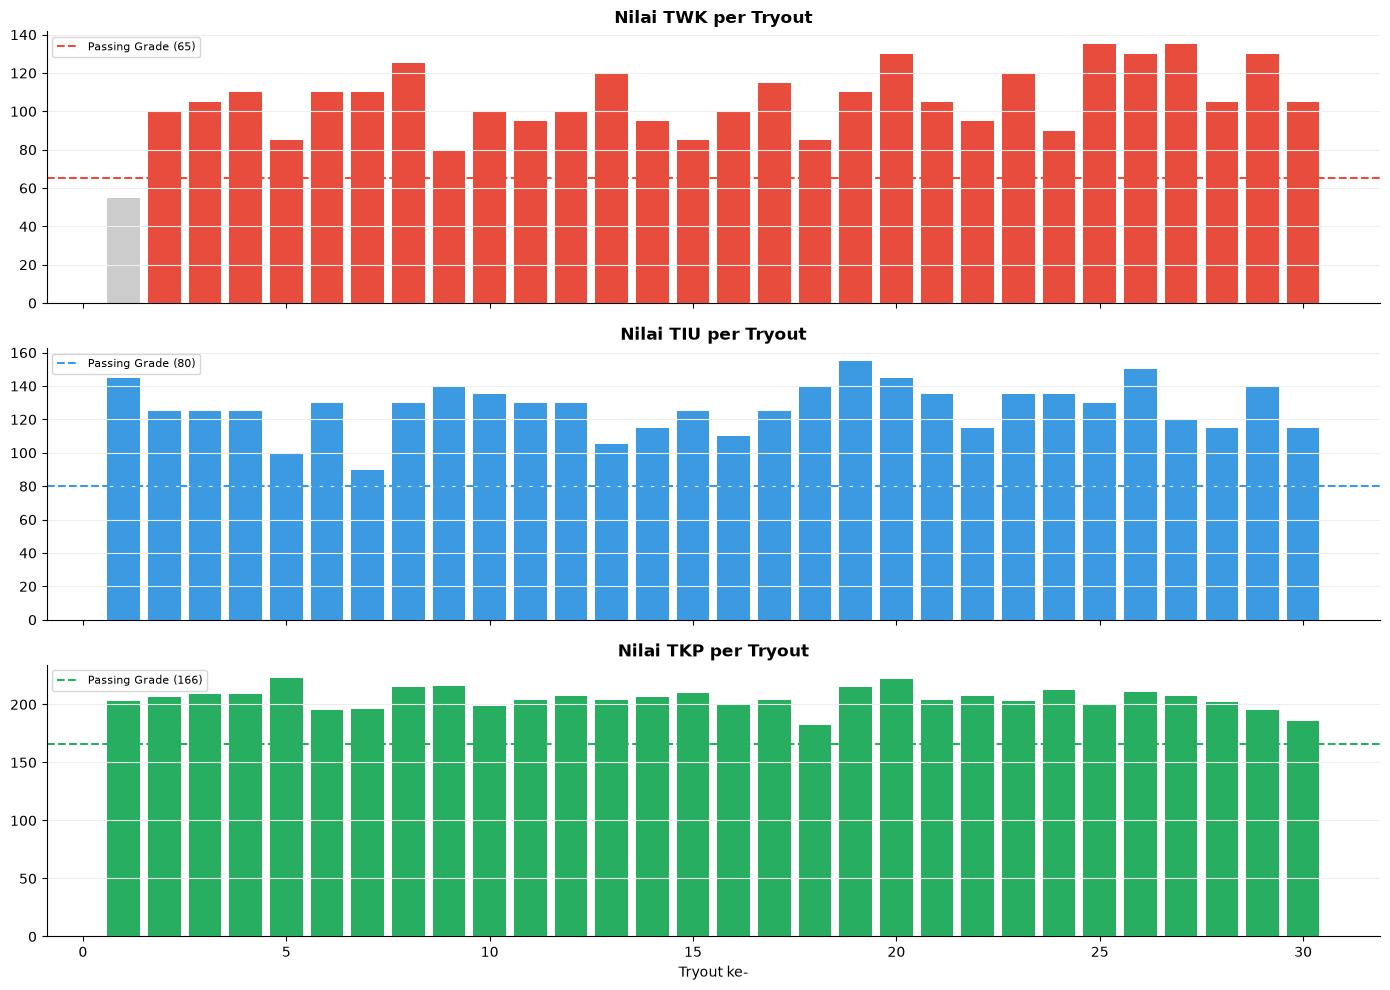

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

komponen = [("TWK", PG_TWK, "#E74C3C"), ("TIU", PG_TIU, "#3B9AE1"), ("TKP", PG_TKP, "#27AE60")]

for ax, (nama, pg, warna) in zip(axes, komponen):
    warna_bar = [warna if v >= pg else "#ccc" for v in df[nama]]
    ax.bar(df["No"], df[nama], color=warna_bar)
    ax.axhline(pg, color=warna, linestyle='--', linewidth=1.5, label=f"Passing Grade ({pg})")
    ax.set_title(f"Nilai {nama} per Tryout", fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(axis='y', color='#eee')
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel("Tryout ke-")
plt.tight_layout()
plt.show()

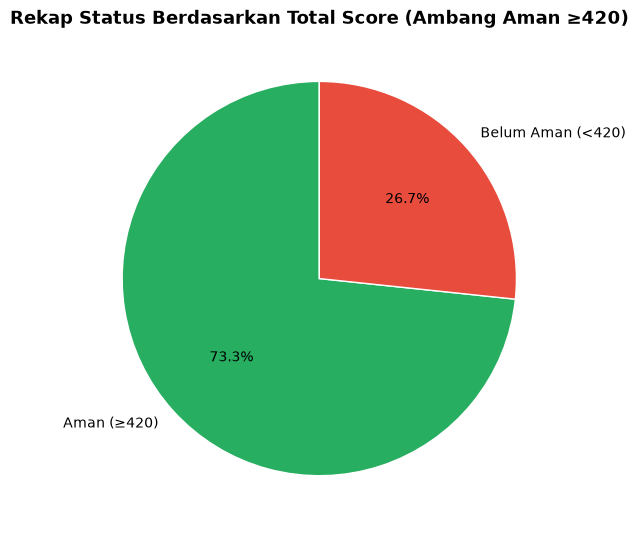

Total tryout: 30
Aman (≥420): 22 kali
Belum Aman (<420): 8 kali
Rata-rata Total Score: 437.7


In [11]:

AMBANG_AMAN = 420

df["Status_Aman"] = df["Total"].apply(lambda x: "Aman (≥420)" if x >= AMBANG_AMAN else "Belum Aman (<420)")

status_count = df["Status_Aman"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#27AE60' if "Aman" in s and "Belum" not in s else '#E74C3C' for s in status_count.index]
ax.pie(status_count, labels=status_count.index, autopct='%1.1f%%',
       colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title("Rekap Status Berdasarkan Total Score (Ambang Aman ≥420)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total tryout: {len(df)}")
print(f"Aman (≥420): {(df['Total']>=AMBANG_AMAN).sum()} kali")
print(f"Belum Aman (<420): {(df['Total']<AMBANG_AMAN).sum()} kali")
print(f"Rata-rata Total Score: {df['Total'].mean():.1f}")

In [12]:
print("=== STATISTIK RINGKAS ===")
print(df[["TWK", "TIU", "TKP", "Total"]].describe().round(1))

=== STATISTIK RINGKAS ===
         TWK    TIU    TKP  Total
count   30.0   30.0   30.0   30.0
mean   105.5  127.2  205.1  437.7
std     18.3   14.7    9.0   26.3
min     55.0   90.0  182.0  396.0
25%     95.0  116.2  200.5  417.8
50%    105.0  130.0  205.0  435.5
75%    118.8  135.0  209.8  454.5
max    135.0  155.0  223.0  497.0


=== FREKUENSI DI BAWAH PASSING GRADE ===
TWK jeblok: 1 dari 30 tryout (3%)
TIU jeblok: 0 dari 30 tryout (0%)
TKP jeblok: 0 dari 30 tryout (0%)


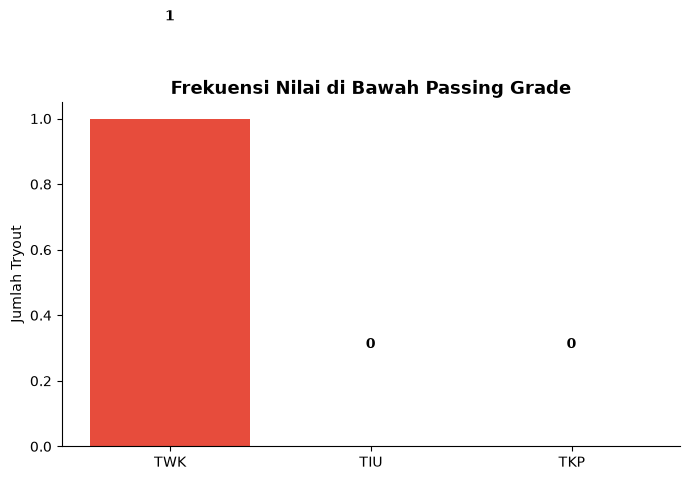

In [13]:
jeblok_twk = (df["TWK"] < PG_TWK).sum()
jeblok_tiu = (df["TIU"] < PG_TIU).sum()
jeblok_tkp = (df["TKP"] < PG_TKP).sum()

print("=== FREKUENSI DI BAWAH PASSING GRADE ===")
print(f"TWK jeblok: {jeblok_twk} dari {len(df)} tryout ({jeblok_twk/len(df)*100:.0f}%)")
print(f"TIU jeblok: {jeblok_tiu} dari {len(df)} tryout ({jeblok_tiu/len(df)*100:.0f}%)")
print(f"TKP jeblok: {jeblok_tkp} dari {len(df)} tryout ({jeblok_tkp/len(df)*100:.0f}%)")

fig, ax = plt.subplots(figsize=(7, 5))
komponen_jeblok = ["TWK", "TIU", "TKP"]
jumlah_jeblok = [jeblok_twk, jeblok_tiu, jeblok_tkp]
bars = ax.bar(komponen_jeblok, jumlah_jeblok, color=["#E74C3C", "#3B9AE1", "#27AE60"])
ax.set_title("Frekuensi Nilai di Bawah Passing Grade", fontsize=13, fontweight='bold')
ax.set_ylabel("Jumlah Tryout")
for bar, val in zip(bars, jumlah_jeblok):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3, str(val), ha='center', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

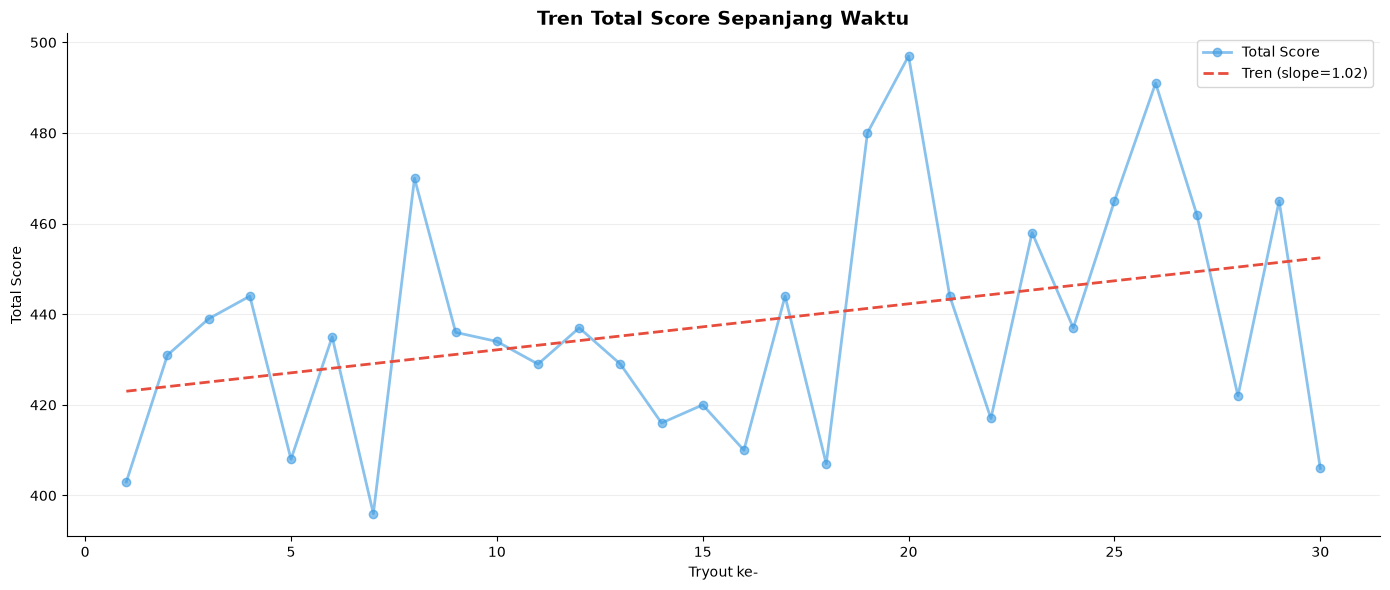

📈 Tren nilai lo NAIK rata-rata 1.02 poin tiap tryout


In [14]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["No"], df["Total"], marker='o', color='#3B9AE1', label='Total Score', linewidth=2, alpha=0.6)

z = np.polyfit(df["No"], df["Total"], 1)
trend = np.poly1d(z)
ax.plot(df["No"], trend(df["No"]), color='#E74C3C', linestyle='--', linewidth=2, label=f'Tren (slope={z[0]:.2f})')

ax.set_title("Tren Total Score Sepanjang Waktu", fontsize=14, fontweight='bold')
ax.set_xlabel("Tryout ke-")
ax.set_ylabel("Total Score")
ax.legend()
ax.grid(axis='y', color='#eee')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

if z[0] > 0:
    print(f"📈 Tren nilai lo NAIK rata-rata {z[0]:.2f} poin tiap tryout")
else:
    print(f"📉 Tren nilai lo TURUN rata-rata {abs(z[0]):.2f} poin tiap tryout")

In [15]:
korelasi = df[["TWK", "TIU", "TKP"]].corr().round(2)
print("=== KORELASI ANTAR KOMPONEN ===")
print(korelasi)
print()
print("Nilai mendekati 1 = makin kuat hubungan positif (naik bareng)")
print("Nilai mendekati 0 = gak ada hubungan jelas")
print("Nilai negatif = kalau satu naik, yang lain cenderung turun")

=== KORELASI ANTAR KOMPONEN ===
      TWK   TIU   TKP
TWK  1.00  0.03  0.02
TIU  0.03  1.00  0.13
TKP  0.02  0.13  1.00

Nilai mendekati 1 = makin kuat hubungan positif (naik bareng)
Nilai mendekati 0 = gak ada hubungan jelas
Nilai negatif = kalau satu naik, yang lain cenderung turun


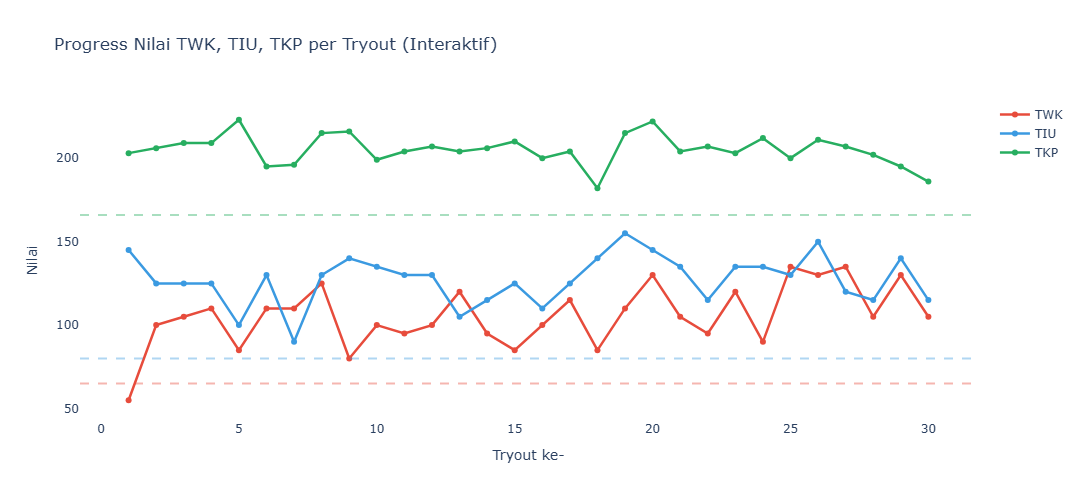

In [16]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=df["No"], y=df["TWK"], mode='lines+markers', name='TWK', line=dict(color='#E74C3C', width=2.5)))
fig.add_trace(go.Scatter(x=df["No"], y=df["TIU"], mode='lines+markers', name='TIU', line=dict(color='#3B9AE1', width=2.5)))
fig.add_trace(go.Scatter(x=df["No"], y=df["TKP"], mode='lines+markers', name='TKP', line=dict(color='#27AE60', width=2.5)))

fig.add_hline(y=PG_TWK, line_dash="dash", line_color="#E74C3C", opacity=0.4)
fig.add_hline(y=PG_TIU, line_dash="dash", line_color="#3B9AE1", opacity=0.4)
fig.add_hline(y=PG_TKP, line_dash="dash", line_color="#27AE60", opacity=0.4)

fig.update_layout(
    title="Progress Nilai TWK, TIU, TKP per Tryout (Interaktif)",
    xaxis_title="Tryout ke-", yaxis_title="Nilai",
    plot_bgcolor='white', paper_bgcolor='white',
    hovermode='x unified', height=500
)
fig.show()

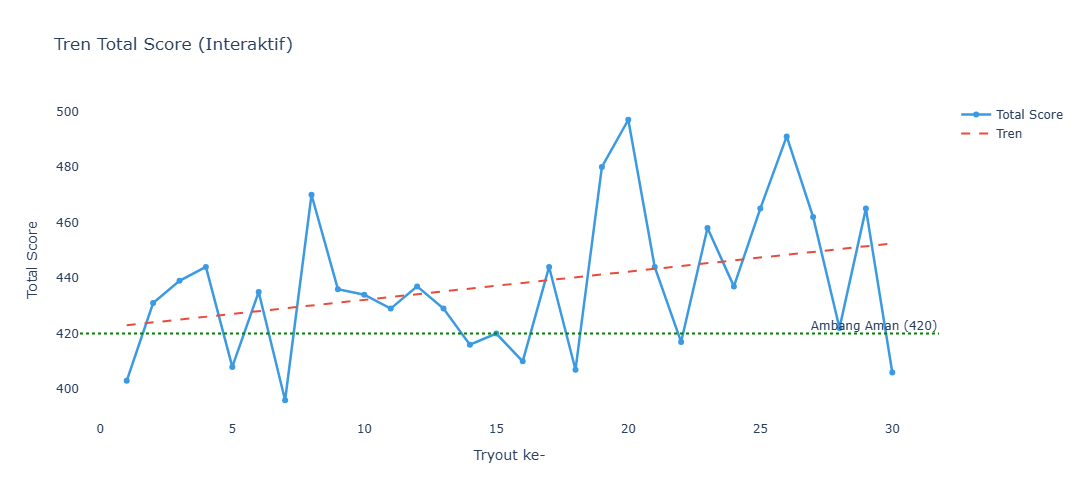

In [17]:
fig2 = go.Figure()

fig2.add_trace(go.Scatter(x=df["No"], y=df["Total"], mode='lines+markers', name='Total Score', line=dict(color='#3B9AE1', width=2.5)))
fig2.add_trace(go.Scatter(x=df["No"], y=trend(df["No"]), mode='lines', name='Tren', line=dict(color='#E74C3C', width=2, dash='dash')))
fig2.add_hline(y=420, line_dash="dot", line_color="green", annotation_text="Ambang Aman (420)")

fig2.update_layout(
    title="Tren Total Score (Interaktif)",
    xaxis_title="Tryout ke-", yaxis_title="Total Score",
    plot_bgcolor='white', paper_bgcolor='white',
    hovermode='x unified', height=500
)
fig2.show()

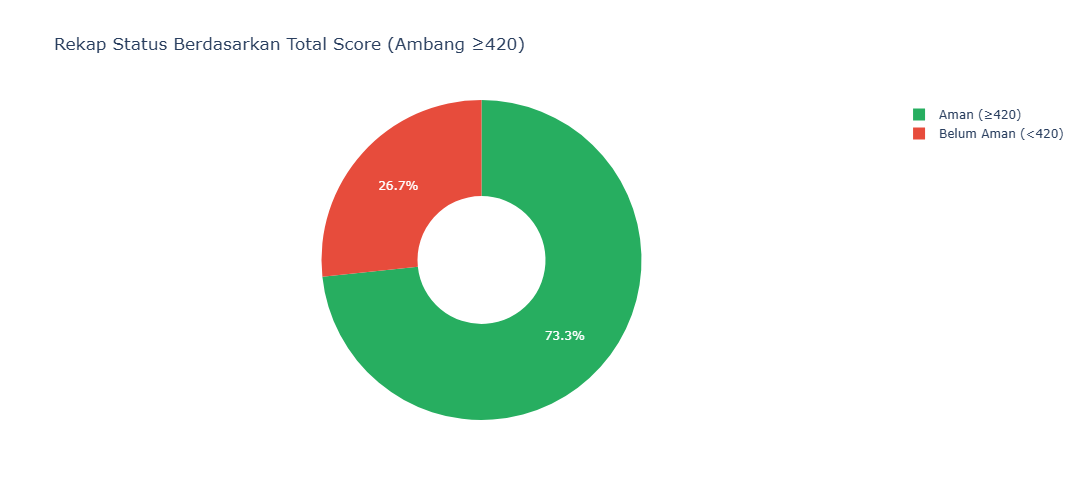

In [18]:
status_count = df["Status_Aman"].value_counts()

fig3 = go.Figure(data=[go.Pie(
    labels=status_count.index, values=status_count.values,
    marker=dict(colors=['#27AE60', '#E74C3C']),
    hole=0.4
)])
fig3.update_layout(title="Rekap Status Berdasarkan Total Score (Ambang ≥420)", height=500)
fig3.show()